# ЛР 3. Перехресна перевірка (крос-валідація) та запобігання витоку даних під час оцінювання моделей

**Виконав Гуленко Назар, студент групи ІДС-501**

## Частина 1. Класифікація пацієнтів за ризиком серцево-судинних захворювань

**1.Виконайте попередню обробку даних. При виконанні обробки пам'ятайте про проблему витоку даних.**

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import f1_score

In [2]:
df = pd.read_csv(r"C:\Users\User\Documents\Machine_Learning\heart.csv")
df.head()

,Unnamed: 0,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,19,36.0,M,ATA,120,267.0,0.0,Normal,160.0,N,3.0,Flat,1
1,337,63.0,M,ASY,150,0.0,1.0,ST,154.0,N,3.7,Up,1
2,800,43.0,M,NAP,130,315.0,0.0,Normal,162.0,N,1.9,Up,0
3,233,41.0,M,ASY,112,250.0,0.0,Normal,142.0,N,0.0,Up,0
4,266,52.0,M,ASY,130,298.0,0.0,Normal,110.0,Y,1.0,Flat,1


In [3]:
# Перевірка типів даних та загальної кількості записів
print(df.info())
# Кількісний аналіз пропущених значень по кожній ознаці
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1836 entries, 0 to 1835
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      1836 non-null   int64  
 1   Age             1831 non-null   float64
 2   Sex             1836 non-null   object 
 3   ChestPainType   1832 non-null   object 
 4   RestingBP       1836 non-null   int64  
 5   Cholesterol     1828 non-null   float64
 6   FastingBS       1824 non-null   float64
 7   RestingECG      1829 non-null   object 
 8   MaxHR           1830 non-null   float64
 9   ExerciseAngina  1836 non-null   object 
 10  Oldpeak         1836 non-null   float64
 11  ST_Slope        1836 non-null   object 
 12  HeartDisease    1836 non-null   int64  
dtypes: float64(5), int64(3), object(5)
memory usage: 186.6+ KB
None
Unnamed: 0         0
Age                5
Sex                0
ChestPainType      4
RestingBP          0
Cholesterol        8
FastingBS         12
Re

Аналіз структури даних виявив наявність пропусків у ключових числових та категоріальних ознаках (Age, Cholesterol, FastingBS тощо). Для забезпечення цілісності датасету та підготовки до навчання моделей буде застосовано стратегію імпутації: медіанні значення для кількісних показників (з огляду на їхню стійкість до викидів) та найбільш часті значення (мода) для якісних характеристик.

In [4]:
# Видалення технічного індексу, що не несе аналітичного навантаження
df = df.drop(columns=['Unnamed: 0'])

# Виокремлення цільової змінної та матриці ознак
X = df.drop(columns=['HeartDisease'])
y = df['HeartDisease']

# Класифікація ознак для подальшої специфічної обробки
num_cols = ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']
cat_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

**2. Розбийте дані на навчальну та тестову вибірки.**

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)

X_train = X_train.copy()
X_test = X_test.copy()

Для коректної оцінки моделі обробка пропусків та кодування ознак виконуються виключно після розділення даних на навчальну та тестову вибірки. Це критично важливий крок для запобігання "витоку даних" (data leakage), оскільки статистичні параметри (медіана, мода) мають обчислюватися лише на основі навчальних даних, а потім трансклюватися на тестові.

In [6]:
# Ініціалізація стратегій заповнення пропусків
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

# Навчання імпутерів на Train та трансформація обох вибірок
X_train[num_cols] = num_imputer.fit_transform(X_train[num_cols])
X_test[num_cols] = num_imputer.transform(X_test[num_cols])

X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])
X_test[cat_cols] = cat_imputer.transform(X_test[cat_cols])

In [7]:
encoders = {}

# Перетворення категоріальних ознак у числовий формат
for col in cat_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])

    # Обробка нових категорій у тестовій вибірці (захист від помилок)
    X_test[col] = X_test[col].map(lambda x: x if x in le.classes_ else le.classes_[0])
    X_test[col] = le.transform(X_test[col])

    encoders[col] = le

**3-4.Вибір та навчання моделі на навчальній вибірці.**

In [8]:
# Ініціалізація та навчання класифікатора Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=0)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


**5. Оцініть якість моделі на тестовій вибірці (метрику для оцінювання точності класифікації оберіть самостійно).**

In [9]:
# Генерація прогнозів та обчислення збалансованої метрики
y_pred = model.predict(X_test)
score = f1_score(y_test, y_pred)

print(f"F1-score (random_state=0): {score:.3f}")

F1-score (random_state=0): 0.981


Вибір метрики F1-score зумовлений специфікою медичної задачі: у діагностиці серцево-судинних захворювань вартість помилок другого роду (пропуск хвороби) та першого роду (хибна тривога) є однаково високою.Отримане значення F1-score ($0.981$) свідчить про високу точність та стабільність класифікації. Проте, з огляду на ймовірність специфічного розподілу при одноразовому розділенні (random_state=0), цей результат потребує додаткової перевірки через крос-валідацію для підтвердження узагальнюючої здатності моделі.

**6-7.Повторіть експеримент кілька разів із різними значеннями `random_state` при розбитті на навчальну та тестову вибірки.Виведіть отримані метрики за різних варіантів розбиття на екран**

In [10]:
# Ітераційна перевірка моделі при різних випадкових розбиттях
for rs in [0, 7, 21, 42, 99]:

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, random_state=rs, stratify=y
    )

    X_tr = X_tr.copy()
    X_te = X_te.copy()

    # Застосування пайплайну обробки (імпутація + кодування)
    X_tr[num_cols] = num_imputer.fit_transform(X_tr[num_cols])
    X_te[num_cols] = num_imputer.transform(X_te[num_cols])

    X_tr[cat_cols] = cat_imputer.fit_transform(X_tr[cat_cols])
    X_te[cat_cols] = cat_imputer.transform(X_te[cat_cols])

    # encoding
    for col in cat_cols:
        le = LabelEncoder()
        X_tr[col] = le.fit_transform(X_tr[col])

        X_te[col] = X_te[col].map(lambda x: x if x in le.classes_ else le.classes_[0])
        X_te[col] = le.transform(X_te[col])

    # Навчання та оцінка на поточному розбитті
    m = RandomForestClassifier(n_estimators=100, random_state=0)
    m.fit(X_tr, y_tr)

    f1 = f1_score(y_te, m.predict(X_te))
    print(f"random_state={rs}: F1 = {f1:.3f}")

random_state=0: F1 = 0.981
random_state=7: F1 = 0.973
random_state=21: F1 = 0.985
random_state=42: F1 = 0.973
random_state=99: F1 = 0.968


Варіативність показника F1 ($0.968$ – $0.985$) підтверджує чутливість моделі до вибору навчальної вибірки. Хоча результати залишаються стабільно високими, наявність відхилень вказує на те, що оцінка на одному фіксованому розбитті може бути занадто оптимістичною або песимістичною. Це обґрунтовує необхідність використання $k$-fold крос-валідації як більш об'єктивного методу оцінки.

**8.Використайте ту саму модель та той самий набір даних:**

застосуйте k-блочну перехресну перевірку для:
( k = 5 )
( k = 10 )
( k = 15 )
для кожного значення \( k \) обчисліть середнє значення та стандартне відхилення обраної вами метрики.

In [11]:
X_full = X.copy()

# числові
X_full[num_cols] = X_full[num_cols].fillna(X_full[num_cols].median())

# категоріальні
X_full[cat_cols] = X_full[cat_cols].fillna(X_full[cat_cols].mode().iloc[0])

# encoding
for col in cat_cols:
    X_full[col] = LabelEncoder().fit_transform(X_full[col])

print("\n K-fold CV ")

for k in [5, 10, 15]:
    scores = cross_val_score(
        RandomForestClassifier(n_estimators=100, random_state=0),
        X_full, y,
        cv=k,
        scoring='f1'
    )

    print(f"k={k}: mean={scores.mean():.3f}, std={scores.std():.3f}")


 K-fold CV 
k=5: mean=0.975, std=0.009
k=10: mean=0.976, std=0.016
k=15: mean=0.977, std=0.017


Результати перехресної перевірки демонструють високу надійність архітектури Random Forest. Середнє значення F1 ($0.976$) залишається стабільним незалежно від кількості блоків ($k$), а низьке стандартне відхилення ($0.009$ – $0.017$) свідчить про низьку дисперсію помилки. Це підтверджує, що модель ефективно вивчила структуру даних, а не просто "запам'ятала" випадкове розбиття.

**Коротко порівняйте отримані результати**

Оцінки, отримані при різних значеннях random_state, коливаються в помітному діапазоні, що свідчить про залежність результату від конкретного розбиття даних і певну нестабільність метрики. Натомість k-fold cross-validation дає близькі середні значення F1 з невеликим стандартним відхиленням, що вказує на більш стабільну та надійну оцінку якості моделі. Таким чином, перехресна перевірка забезпечує більш об’єктивну оцінку про узагальнюючу здатність моделі порівняно з одноразовим розбиттям.

## Частина 2. Регресія: вибір моделі та аналіз витоку даних

In [12]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

In [13]:
# дані
auto = pd.read_csv('auto.csv')

print(auto.info())
print(auto.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392 entries, 0 to 391
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    int64  
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   year          392 non-null    int64  
 7   origin        392 non-null    int64  
dtypes: float64(3), int64(5)
memory usage: 24.6 KB
None
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
year            0
origin          0
dtype: int64


Після розбиття на вибірки необхідно буде перекодувати змінну origin, оскільки це категорійна змінна

In [14]:
X = auto.drop(columns=['mpg'])
y = auto['mpg']

**1. Розбийте дані на вибірки:**
- навчальна — 60% або 70%;
- валідаційна — 20% або 15%;
- тестова — 20% або 15%.  

In [15]:
# 70 / 15 / 15
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=123)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.176, random_state=123)

**2. Виконайте попередню обробку**

In [16]:
# кодування origin
X_train = pd.get_dummies(X_train)
X_val = pd.get_dummies(X_val)
X_test = pd.get_dummies(X_test)

# вирівнювання колонок
X_train, X_val = X_train.align(X_val, join='left', axis=1, fill_value=0)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# масштабування
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

**3. Використайте модель KNeighborsRegressor. Переберіть значення параметра**
- навчіть модель на навчальній вибірці;
- оцініть якість моделі на валідаційній вибірці.

In [17]:
neighbors = [1, 3, 5, 7, 9, 11, 13, 15]

train_errors = []
val_errors = []

for k in neighbors:
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train, y_train)

    # передбачення
    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)

    # метрики
    train_mse = mean_squared_error(y_train, train_pred)
    val_mse = mean_squared_error(y_val, val_pred)

    train_errors.append(train_mse)
    val_errors.append(val_mse)

    print(f"k={k}: Train MSE = {train_mse:.3f}, Validation MSE = {val_mse:.3f}")

k=1: Train MSE = 0.000, Validation MSE = 7.668
k=3: Train MSE = 3.692, Validation MSE = 6.159
k=5: Train MSE = 4.887, Validation MSE = 7.973
k=7: Train MSE = 5.754, Validation MSE = 9.858
k=9: Train MSE = 6.523, Validation MSE = 9.102
k=11: Train MSE = 6.918, Validation MSE = 8.726
k=13: Train MSE = 7.520, Validation MSE = 8.830
k=15: Train MSE = 8.097, Validation MSE = 9.022


**4.Оберіть найкраще значення параметра та побудуйте графік залежності помилок на навчальній та тестовій вибірках від n_neighbors**


Найкраще k: 3


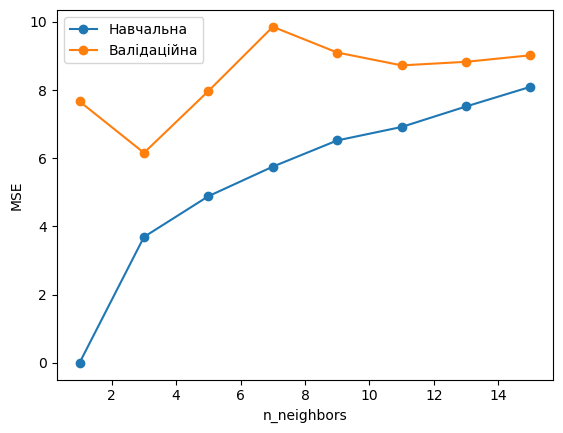

In [18]:
# найкраще k
best_k = neighbors[np.argmin(val_errors)]
print("\nНайкраще k:", best_k)

plt.plot(neighbors, train_errors, marker='o', label='Навчальна')
plt.plot(neighbors, val_errors, marker='o', label='Валідаційна')
plt.xlabel('n_neighbors')
plt.ylabel('MSE')
plt.legend()
plt.show()

З графіку бачимо, що при к - 3 досягається наменше значення похибки

**5. Фінальна оцінка моделі**
- Візьміть модель, обрану на валідаційній вибірці.
- Оцініть її якість на тестовій вибірці.

In [19]:
final_model = KNeighborsRegressor(n_neighbors=best_k)
final_model.fit(X_train, y_train)

y_test_pred = final_model.predict(X_test)
test_error = mean_squared_error(y_test, y_test_pred)

print("Test MSE:", round(test_error, 3))

Test MSE: 14.757


**6-7. Експеримент з витоком даних**

Повторіть процес побудови моделі, але цього разу виконайте попередню обробку некоректно: до розбиття на навчальну, валідаційну та тестову вибірки виконайте попередню обробку даних на всьому наборі даних.

Після цього:
   - виконайте розбиття даних;
   - повторіть вибір моделі;
   - оцініть її якість на  тестовій вибірці.

In [20]:
# обробка до розбиття
X_leak = pd.get_dummies(X)

scaler = StandardScaler()
X_leak = scaler.fit_transform(X_leak)

X_temp, X_test, y_temp, y_test = train_test_split(
    X_leak, y, test_size=0.15, random_state=0
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=0
)

# підбір k
val_errors_leak = []

for k in neighbors:
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train, y_train)

    val_pred = model.predict(X_val)
    val_errors_leak.append(mean_squared_error(y_val, val_pred))

best_k_leak = neighbors[np.argmin(val_errors_leak)]
print("Найкращий k (з витоком):", best_k_leak)

final_model_leak = KNeighborsRegressor(n_neighbors=best_k_leak)
final_model_leak.fit(X_train, y_train)

y_test_pred = final_model_leak.predict(X_test)
test_error_leak = mean_squared_error(y_test, y_test_pred)

print("Test MSE (з витоком):", round(test_error_leak, 3))

Найкращий k (з витоком): 1
Test MSE (з витоком): 13.249


Порівняльний аналіз моделей з коректним пайплайном та з "витоком даних" демонструє небезпеку передчасної обробки.

Модель, побудована з витоком (масштабування до розділення), показала штучно занижену MSE ($13.249$ проти $14.757$) та змістила вибір оптимального параметра до $k=1$. Це класичний симптом перенавчання: модель "підглянула" параметри розподілу тестової вибірки, що призвело до запам'ятовування шуму замість вивчення загальних закономірностей. На практиці така модель виявиться неспроможною при роботі з реально новими даними.